In [1]:
# importing libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

In [2]:
df = pd.read_csv("D:/Programs/DataScienceProjects/House-Rent-Prediction/data/raw/House_Rent_Dataset.csv")

In [3]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [103]:
# getting more info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [104]:
# checking any null values 
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [105]:
# getting more statistical info
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [106]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [107]:
df['Area Type'].unique()

array(['Super Area', 'Carpet Area', 'Built Area'], dtype=object)

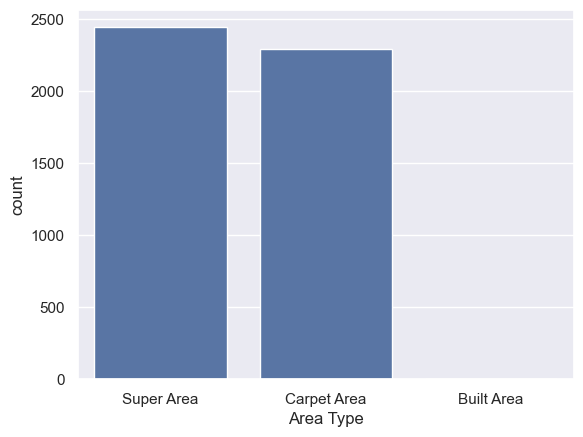

In [108]:
plt.Figure(figsize=(10,7))
sns.countplot(data=df,x='Area Type')
plt.show()

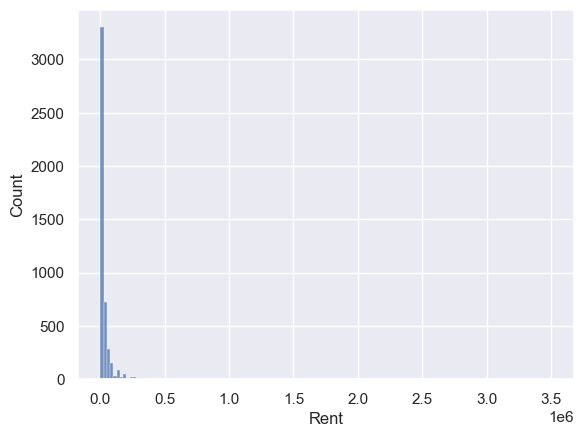

In [109]:
plt.Figure(figsize=(12,6))
sns.histplot(data=df,x='Rent')
plt.show()

price is right skewed  we need to remove some outliers and apply log transform

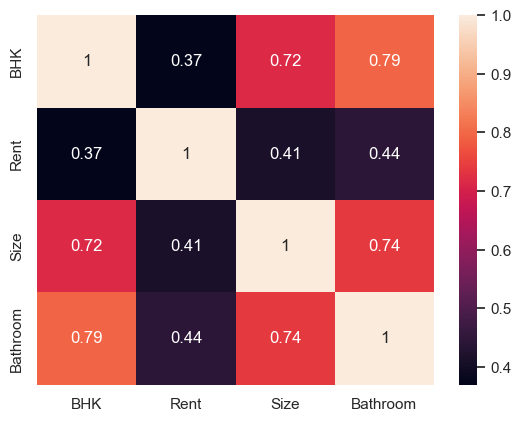

In [110]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.show()

BHK, Size, Bathroom are showing positve correleation with Rent

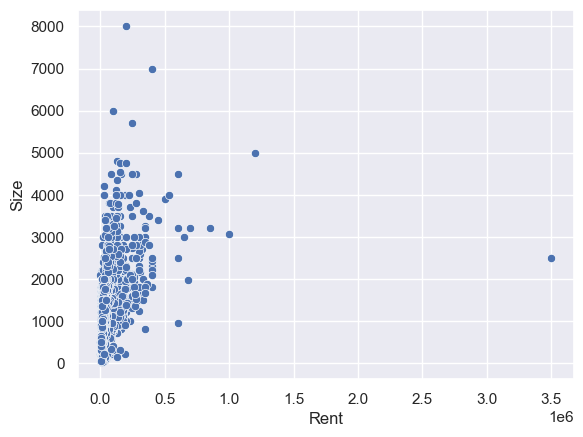

In [111]:
sns.scatterplot(data=df, x='Rent',y='Size')
plt.show()

In [5]:
df.drop(columns=['Posted On'],inplace=True)

### Preprocessing

In [112]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.head()


,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [7]:
df['Floor'].str.split(" ").str[0].unique()

array(['Ground', '1', '2', '4', '3', '5', '7', '8', 'Upper', '11',
       'Lower', '6', '14', '43', '13', '18', '17', '9', '19', '60', '34',
       '12', '26', '25', '53', '16', '10', '39', '32', '47', '28', '20',
       '15', '65', '40', '37', '22', '21', '30', '35', '33', '44', '41',
       '46', '27', '45', '48', '50', '24', '23', '29', '49', '36', '76'],
      dtype=object)

In [115]:
df[(df['Floor'].str.split(" ").str[0]=='Upper')]

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
290,2022-06-29,1,3500,200,Upper Basement out of 4,Super Area,Baguihati,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
549,2022-06-02,2,8000,650,Upper Basement out of 9,Carpet Area,"Nakoda Heights, Nalasopara",Mumbai,Semi-Furnished,Family,2,Contact Agent
559,2022-05-22,1,30000,488,Upper Basement out of 16,Carpet Area,"Kyraa Ariso Apartment, Chembur",Mumbai,Semi-Furnished,Bachelors/Family,2,Contact Owner
631,2022-06-04,4,310000,2600,Upper Basement out of 20,Carpet Area,Lokhandwala Complex,Mumbai,Unfurnished,Family,4,Contact Agent
633,2022-07-06,3,65000,950,Upper Basement out of 9,Carpet Area,Tilak Nagar - Harbour Line,Mumbai,Semi-Furnished,Bachelors/Family,3,Contact Agent
635,2022-05-18,3,150000,1330,Upper Basement out of 40,Carpet Area,Lodha Ajuro tower lalbag,Mumbai,Unfurnished,Bachelors/Family,3,Contact Agent
694,2022-07-09,3,55000,900,Upper Basement out of 10,Carpet Area,Chikuwadi,Mumbai,Semi-Furnished,Family,2,Contact Agent
722,2022-06-04,2,100000,750,Upper Basement out of 30,Carpet Area,"Lodha NCP Commercial , Wadala",Mumbai,Unfurnished,Bachelors/Family,2,Contact Agent
952,2022-06-24,3,160000,2000,Upper Basement out of 30,Carpet Area,"Flora Heights, Andheri West",Mumbai,Furnished,Family,3,Contact Agent
1098,2022-04-29,1,25000,400,Upper Basement out of 7,Carpet Area,shanti kutir tunga village powai,Mumbai,Unfurnished,Bachelors/Family,1,Contact Owner


In [116]:
df[(df['Floor'].str.split(" ").str[0]=='Lower')]

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
518,2022-06-08,2,45000,1320,Lower Basement out of 2,Super Area,Ballygunge,Kolkata,Furnished,Bachelors/Family,2,Contact Owner
1070,2022-07-06,3,45000,985,Lower Basement out of 18,Carpet Area,"Gemstar Symphony Apartment, Kandivali West",Mumbai,Unfurnished,Family,3,Contact Agent
2133,2022-07-02,2,13000,850,Lower Basement out of 2,Carpet Area,Sun City Layout,Bangalore,Semi-Furnished,Family,2,Contact Owner
2369,2022-06-24,2,10000,700,Lower Basement out of 3,Carpet Area,"Jp Nagar Phase 5, J P Nagar, Outer Ring Road",Bangalore,Semi-Furnished,Bachelors,2,Contact Owner
3091,2022-05-15,2,15000,2800,Lower Basement out of 1,Carpet Area,Pudur,Chennai,Unfurnished,Family,2,Contact Owner
3268,2022-04-30,2,8000,800,Lower Basement out of 3,Carpet Area,"Kamakshiamman Nagar Layout, Iyyappanthangal",Chennai,Unfurnished,Bachelors/Family,2,Contact Owner
3454,2022-06-20,3,20000,1500,Lower Basement out of 1,Carpet Area,Oragadam,Chennai,Unfurnished,Bachelors/Family,2,Contact Owner
3463,2022-06-18,1,8000,360,Lower Basement out of 1,Super Area,Mogappair West,Chennai,Semi-Furnished,Bachelors/Family,1,Contact Owner
4457,2022-07-06,4,400000,7000,Lower Basement out of 2,Carpet Area,Jubilee Hills,Hyderabad,Semi-Furnished,Bachelors/Family,6,Contact Agent
4736,2022-06-28,3,15000,1500,Lower Basement out of 2,Super Area,Almasguda,Hyderabad,Semi-Furnished,Family,3,Contact Owner


In [8]:
df['Floor'] = df['Floor'].str.split(" ").str[0]
df['Floor'].unique()

array(['Ground', '1', '2', '4', '3', '5', '7', '8', 'Upper', '11',
       'Lower', '6', '14', '43', '13', '18', '17', '9', '19', '60', '34',
       '12', '26', '25', '53', '16', '10', '39', '32', '47', '28', '20',
       '15', '65', '40', '37', '22', '21', '30', '35', '33', '44', '41',
       '46', '27', '45', '48', '50', '24', '23', '29', '49', '36', '76'],
      dtype=object)

In [9]:
df['Floor'] = df['Floor'].replace({'Ground': 0,'Upper':0,'Lower':0})

In [17]:
df['Floor'].unique()

array([ 0,  1,  2,  4,  3,  5,  7,  8, 11,  6, 14, 43, 13, 18, 17,  9, 19,
       60, 34, 12, 26, 25, 53, 16, 10, 39, 32, 47, 28, 20, 15, 65, 40, 37,
       22, 21, 30, 35, 33, 44, 41, 46, 27, 45, 48, 50, 24, 23, 29, 49, 36,
       76])

In [120]:
df['Floor'].dropna(axis=0,inplace=True)

In [121]:
df.shape

(4746, 12)

In [122]:
df = df.dropna()

In [15]:
df['Floor']=df['Floor'].astype(int)

In [124]:
df.shape

(4746, 12)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   BHK                4746 non-null   int64 
 1   Rent               4746 non-null   int64 
 2   Size               4746 non-null   int64 
 3   Floor              4746 non-null   int64 
 4   Area Type          4746 non-null   object
 5   Area Locality      4746 non-null   object
 6   City               4746 non-null   object
 7   Furnishing Status  4746 non-null   object
 8   Tenant Preferred   4746 non-null   object
 9   Bathroom           4746 non-null   int64 
 10  Point of Contact   4746 non-null   object
dtypes: int64(5), object(6)
memory usage: 408.0+ KB


In [126]:
df['Area Locality'].value_counts()

Area Locality
Bandra West             37
Gachibowli              29
Electronic City         24
Miyapur, NH 9           22
Velachery               22
                        ..
Sangareddy District      1
Punjagutta X Roads       1
Rodamestri Nagar         1
B.S.Maktha               1
Manikonda, Hyderabad     1
Name: count, Length: 2235, dtype: int64

In [12]:
df['Area Type'].value_counts()

Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

In [11]:
df['Point of Contact'].value_counts()

Point of Contact
Contact Owner      3216
Contact Agent      1529
Contact Builder       1
Name: count, dtype: int64

In [129]:
df['Bathroom'].value_counts()

Bathroom
2     2291
1     1474
3      749
4      156
5       60
6       12
7        3
10       1
Name: count, dtype: int64

In [130]:
df['City'].value_counts()

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64

In [131]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

In [132]:
df['Tenant Preferred'].value_counts()

Tenant Preferred
Bachelors/Family    3444
Bachelors            830
Family               472
Name: count, dtype: int64

In [13]:
df["Area Type"] = df["Area Type"].replace("Built Area", "Super Area")
df['Area Type'].unique()

array(['Super Area', 'Carpet Area'], dtype=object)

In [133]:
df["Point of Contact"] = df["Point of Contact"].replace(
    "Contact Builder", "Contact Agent"
)


In [134]:
df["Bathroom"] = df["Bathroom"].apply(lambda x: 5 if x >= 5 else x)

### Feature Engineering

In [158]:
# applying log transformation on rent col
df["Rent"] = np.log1p(df["Rent"])

In [159]:
target = "Rent"  # or "Rent_log"

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop(target)
cat_cols = df.select_dtypes(include="object").columns

In [160]:
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,9.210440,1100,0,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,9.903538,800,1,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,9.741027,1000,1,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,9.210440,800,1,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,8.922792,850,1,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [161]:
target = "Rent"   # or "Rent"

low_card_cols = [
    "Area Type",
    "City",
    "Furnishing Status",
    "Tenant Preferred",
    "Point of Contact"
]

high_card_cols = [
    "Area Locality"
]

num_cols = [
    "BHK",
    "Size",
    "Floor",
    "Bathroom"
]


In [162]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

In [163]:
# target encoding for area locality

from category_encoders import TargetEncoder

te = TargetEncoder(cols = high_card_cols)

X_train[high_card_cols] = te.fit_transform(X_train[high_card_cols],y_train)

X_test[high_card_cols] = te.transform(X_test[high_card_cols])

In [164]:
# one-hot encoding for low cardinality cols

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore',
                    sparse_output=False)

ohe_train = ohe.fit_transform(X_train[low_card_cols])
ohe_test = ohe.transform(X_test[low_card_cols])

ohe_cols = ohe.get_feature_names_out(low_card_cols)

ohe_train_df = pd.DataFrame(ohe_train,
                            columns=ohe_cols,
                            index=X_train.index)

ohe_test_df = pd.DataFrame(ohe_test,
                            columns=ohe_cols,
                            index=X_test.index)

In [165]:
ohe_train_df.head()

,Area Type_Carpet Area,Area Type_Super Area,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Furnished,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Point of Contact_Contact Agent,Point of Contact_Contact Owner
1995,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1497,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2763,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1351,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
1862,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [166]:
X_train = X_train.drop(columns=low_card_cols)
X_test = X_test.drop(columns=low_card_cols)

In [ ]:
X_train_final = pd.concat([X_train[num_cols+ high_card_cols], ohe_train_df],axis=1)
X_test_final = pd.concat([X_test[num_cols+ high_card_cols], ohe_test_df], axis=1)

In [168]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

### model training

In [170]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [172]:
y_predict_log = model.predict(X_test_final)

In [173]:
y_predict  = np.expm1(y_predict_log)

### model evaluation

In [175]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [185]:
y_test_actual = np.expm1(y_test)
y_pred_actual = y_predict

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)


In [187]:
print("mean absolute error",mae)
print("r sqauare",r2)

mean absolute error 13448.99925462798
r sqauare 0.15225548501521924


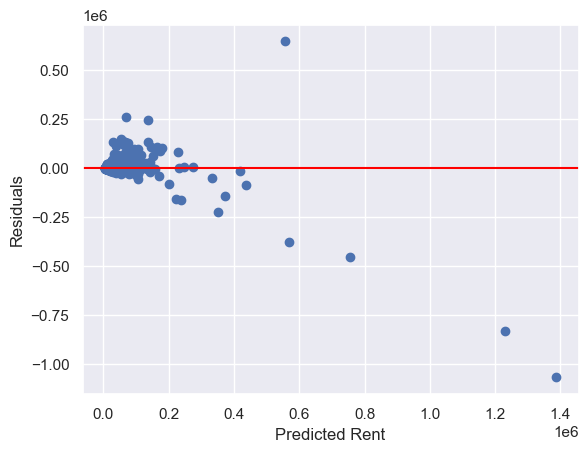

In [180]:
residuals = y_test_actual - y_pred_actual

plt.scatter(y_pred_actual, residuals)
plt.axhline(0, color="red")
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.show()


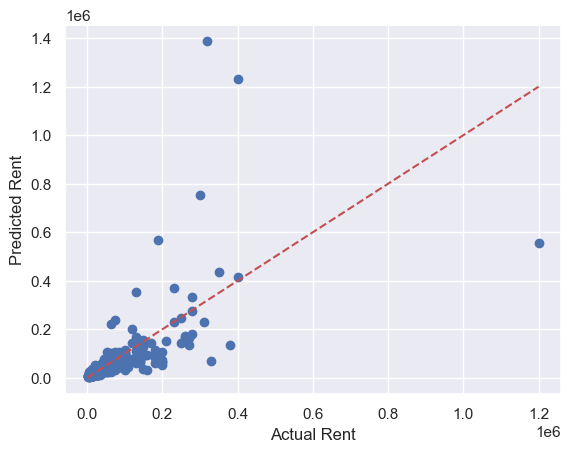

In [181]:
plt.scatter(y_test_actual, y_pred_actual)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--"
)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.show()


In [188]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [189]:
# Initialize Ridge model
ridge_model = Ridge(alpha=10.0, random_state=42)

# Train
ridge_model.fit(X_train_final, y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",42


In [190]:
# Predict on log scale
y_pred_log = ridge_model.predict(X_test_final)


In [191]:
# Convert back to original rent scale
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)

In [192]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : ₹{mae:,.2f}")
print(f"R²   : {r2:.4f}")


MAE  : ₹12,423.57
R²   : 0.4076


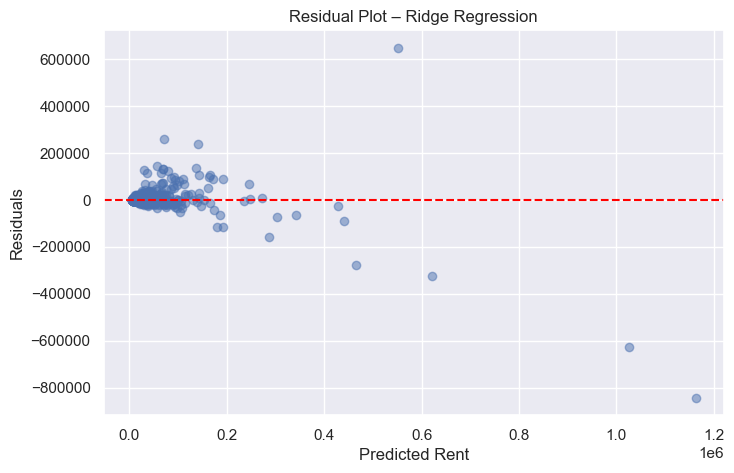

In [193]:
import matplotlib.pyplot as plt

residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,5))
plt.scatter(y_pred_actual, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.title("Residual Plot – Ridge Regression")
plt.show()


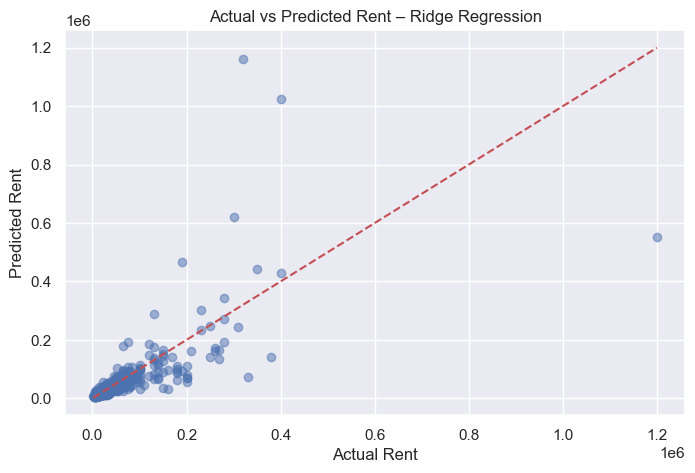

In [194]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--"
)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent – Ridge Regression")
plt.show()


In [195]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)


In [196]:
rf_model.fit(X_train_final, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [197]:
y_pred_log = rf_model.predict(X_test_final)


In [198]:
y_test_actual = np.expm1(y_test)
y_pred_actual = np.expm1(y_pred_log)


In [199]:
mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : ₹{mae:,.2f}")
print(f"R²   : {r2:.4f}")


MAE  : ₹12,085.77
R²   : 0.6009


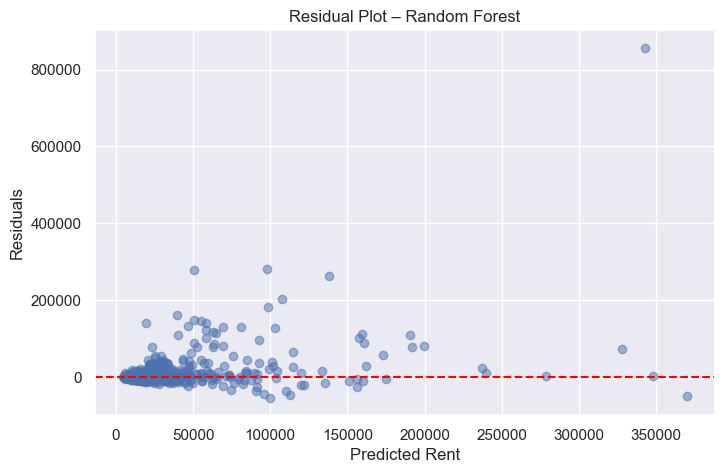

In [200]:
import matplotlib.pyplot as plt

residuals = y_test_actual - y_pred_actual

plt.figure(figsize=(8,5))
plt.scatter(y_pred_actual, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Rent")
plt.ylabel("Residuals")
plt.title("Residual Plot – Random Forest")
plt.show()


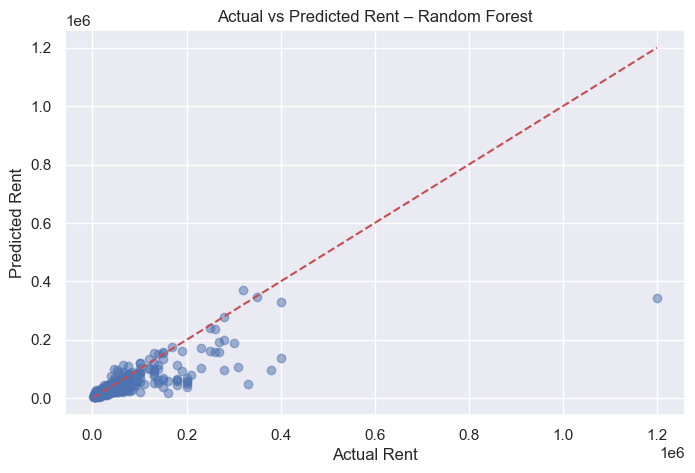

In [201]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    "r--"
)
plt.xlabel("Actual Rent")
plt.ylabel("Predicted Rent")
plt.title("Actual vs Predicted Rent – Random Forest")
plt.show()


In [202]:

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

Area Locality                     0.368085
Bathroom                          0.108245
BHK                               0.092727
Size                              0.091188
Point of Contact_Contact Owner    0.088338
City_Mumbai                       0.080618
Point of Contact_Contact Agent    0.068675
Floor                             0.038031
Area Type_Carpet Area             0.011371
Area Type_Super Area              0.009036
dtype: float64


In [205]:
import joblib
import os

dir_name = 'models'

joblib.dump(te, os.path.join(dir_name,"area_locality_encoder.pkl"))
joblib.dump(ohe, os.path.join(dir_name, "low_card_ohe.pkl"))
joblib.dump(scaler, os.path.join(dir_name, "num_scaler.pkl"))
joblib.dump(rf_model, os.path.join(dir_name, "rent_model.pkl"))

['models\\rent_model.pkl']